Importing Libraries

In [2]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')
print('Libraries Loaded')

Libraries Loaded


Load & Inspect

In [9]:

df = sns.load_dataset('taxis')
df.head()  # Verified if dataset is loaded

#Print Shape
print(df.shape)

# Show first rows
df.head()

# Structural info
df.info()
'''
As per the info provided below are the columns with null values.
Total Entries = 6433
 9   payment          6389 non-null   object
 10  pickup_zone      6407 non-null   object
 11  dropoff_zone     6388 non-null   object
 12  pickup_borough   6407 non-null   object
13  dropoff_borough  6388 non-null   object
'''

# Numeric Summery
df.describe()

(6433, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


Clean & Prepare

In [25]:

df2 = df.copy() # Copying the dataframe to keep original records

#Applying Transformations on Copied df

df2['payment'] = df2['payment'].fillna(df2['payment'].mode()[0])

df2['pickup_zone'] = df2['pickup_zone'].fillna(df2['pickup_zone'].mode()[0])

df2['pickup_borough'] = df2['pickup_borough'].fillna(df2['pickup_borough'].mode()[0])

df2['dropoff_zone'] = df2['dropoff_zone'].fillna(df2['dropoff_zone'].mode()[0])

df2['dropoff_borough'] = df2['dropoff_borough'].fillna(df2['dropoff_borough'].mode()[0])

# Transforming DataTime into Date format for better statistics

df2['pickup'] = df2['pickup'].dt.strftime('%d-%m-%Y')

df2['dropoff'] = df2['dropoff'].dt.strftime('%d-%m-%Y')

'''
We have used mode as three columns were non integers, usage of other methods are not advisable.
'''

#Verification Post Clean
df2.info()
print(df2.isnull().sum())  # Validating Null Count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pickup           6433 non-null   object 
 1   dropoff          6433 non-null   object 
 2   passengers       6433 non-null   int64  
 3   distance         6433 non-null   float64
 4   fare             6433 non-null   float64
 5   tip              6433 non-null   float64
 6   tolls            6433 non-null   float64
 7   total            6433 non-null   float64
 8   color            6433 non-null   object 
 9   payment          6433 non-null   object 
 10  pickup_zone      6433 non-null   object 
 11  dropoff_zone     6433 non-null   object 
 12  pickup_borough   6433 non-null   object 
 13  dropoff_borough  6433 non-null   object 
dtypes: float64(5), int64(1), object(8)
memory usage: 703.7+ KB
pickup             0
dropoff            0
passengers         0
distance           0
fare     

In [26]:
# Test Field to understand the data of the table

df2.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,23-03-2019,23-03-2019,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,04-03-2019,04-03-2019,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,27-03-2019,27-03-2019,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,10-03-2019,10-03-2019,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,30-03-2019,30-03-2019,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


Statistics

In [40]:

# Total amount paid based on payment mode

payment_stats = (
    df2.groupby(['payment']).agg({
        'total': 'sum'
    }).reset_index()
)

payment_stats.columns = ['Payment Mode', 'Total Amount Paid']
payment_stats

# Total number of passengers for Each Day

passenger_stats = (
    df2.groupby(['pickup']).agg({
        'passengers' : 'sum'
    }).reset_index()
)
passenger_stats.columns = ['Travel Date', 'No of Passengers']
passenger_stats

# Average Tip and Fare per day

average_tip_fare = (
    df2.groupby(['pickup']).agg({
        'tip' : 'mean',
        'fare' : 'mean'
    }).reset_index()
)
average_tip_fare.columns = ['Travel Date', 'Average Tip', 'Average Fare']
average_tip_fare['Average Tip'] = average_tip_fare['Average Tip'].round(2)
average_tip_fare['Average Fare'] = average_tip_fare['Average Fare'].round(2)
average_tip_fare


,Travel Date,Average Tip,Average Fare
0,01-03-2019,1.84,12.23
1,02-03-2019,1.69,11.91
2,03-03-2019,1.82,12.95


#Visualize

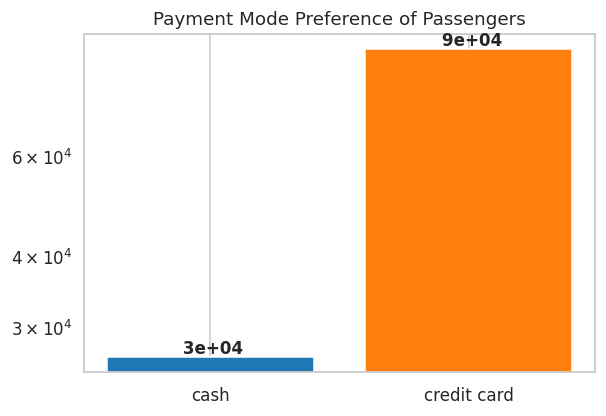

In [34]:
# Normal Bar Graph

fig, ax = plt.subplots(figsize = (6,4))

payment_bars = ax.bar(payment_stats['Payment Mode'], payment_stats['Total Amount Paid'], color = ['tab:blue', 'tab:orange'])
for bar, val in zip(payment_bars, payment_stats['Total Amount Paid']) :
  ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() + 0.01, f"{val: .0}", ha='center', va='bottom', fontsize = 11, fontweight = 'bold')
ax.set_title('Payment Mode Preference of Passengers')
ax.set_yscale('log')
plt.show()

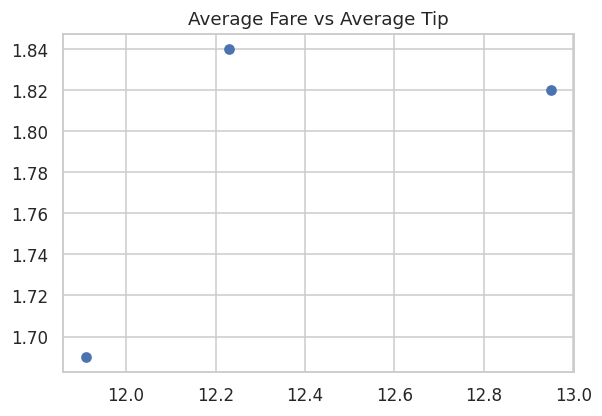

In [45]:
# Scatter Plot

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (6,4))
plt.scatter(
    average_tip_fare['Average Fare'],
    average_tip_fare['Average Tip']
)
plt.title('Average Fare vs Average Tip')
plt.show()

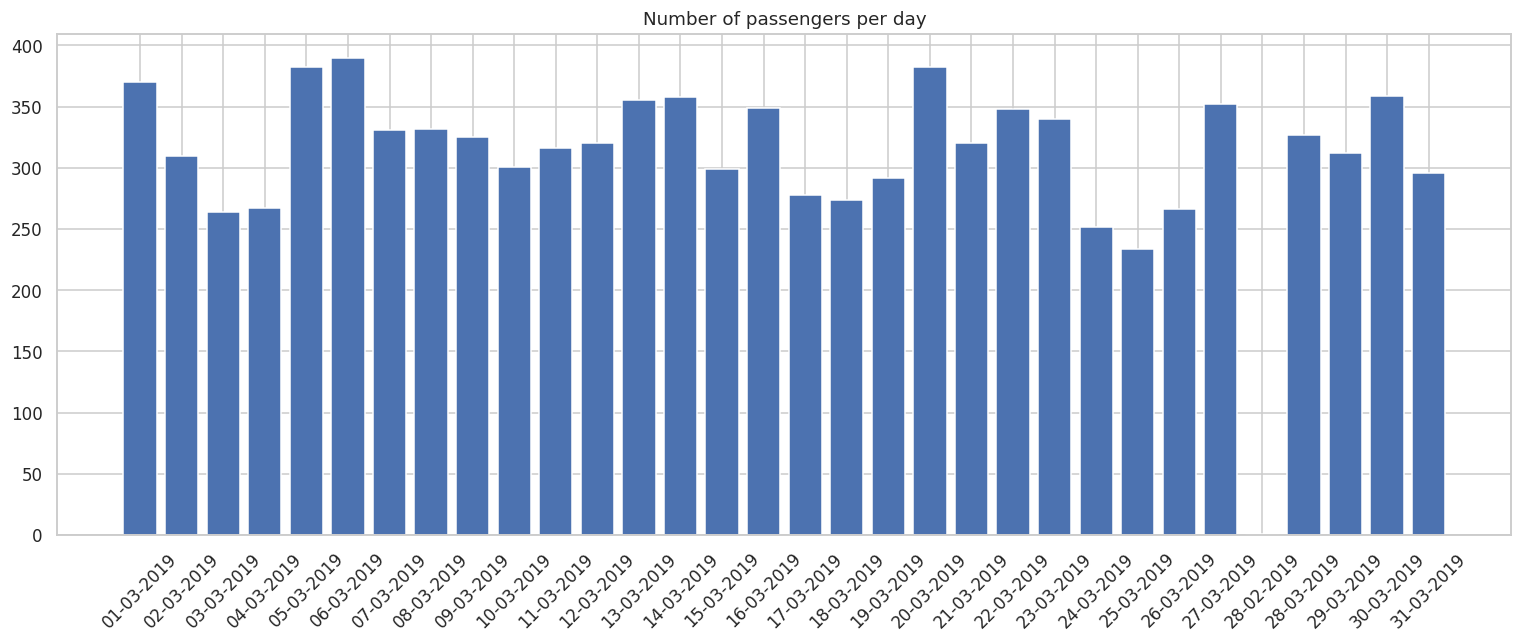

In [54]:
fig, ax = plt.subplots(figsize = (14,6))
# passenger_stats.columns = ['Travel Date', 'No of Passengers']
passenger_bars = ax.bar(passenger_stats['Travel Date'], passenger_stats['No of Passengers'])
ax.set_title('Number of passengers per day')
plt.xticks(rotation = 45)  # Since Days were overlapping so titled the title to avoid overlap in x-axis
plt.tight_layout()
plt.show()

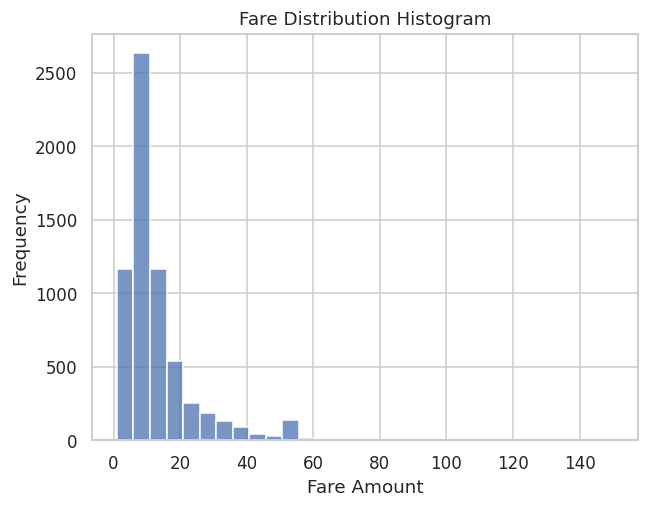

In [55]:
#Histogram

sns.histplot(df2['fare'], bins = 30 )
plt.title('Fare Distribution Histogram')
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.show()

Key Insights

Please find key insights based on above graphs

1.   Payment Mode Preference of Passengers : Checking the bar graph it is quite clear that users prefer to use credit card rather than cash to pay.
2.   Average Fare vs Average Tip: Scatter graph suggests the dependecy on average fare and average tip. Tip added by customers is quite low when taxi fare is less. Meanwhile as price increases, drastic increase in tip can be observed. Later point tip decreases gradually stating that customer has set a fixed amount and they don't prefer to pay more tip if fare is at highest.


1.   Number of passengers per day: Bar graph is repeated as bar graph is the best plot to show the overall count. Observing the graph we can conclude that everyday atleast 200+ people travel using taxi.
2.   Fare Distribution Histogram: Histogram provides insights that the max taxi fare is set to 60. Considering so we can predict that if we are booking a taxi, the fare of taxi would be between 0-20.









Narrative Conclusion

Instead of looping through tables or datasets everytime we require any statistics, plotting related data with relevant graph could reduce the effort of iterating through numbers. Graphs are not only visually attractive but also quite helpful to conclude multiple insights that would require multistep mathematical and statistical calculations.